<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExOWI5emc0dnp2Z24ycDJibGkxbmM1ZjU2aDdqaW5yODdic3JzZjMxcyZlcD12MV9naWZzX3NlYXJjaCZjdD1n/1gXg8Hrjah7bmm45W7/giphy.webp" alt="Eigen" width="500" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Examples of Solution Eigen values & Eigen Vectors</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Seismic Desing</p>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

### Libraries

In [1]:
import sys
import os
import glob
from pathlib import Path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
from numpy.linalg import eig, inv  
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from repo_seismic_desing import *

## Example
![alt text](image-10.png)

#### Data

In [3]:
ProjecName = 'Edifico Rivadavia'

h = 3.6                                                                                                                         # Height of a single floor [m]
sto = 3                                                                                                                         # Number of floors
H = np.ones(sto) * h                                                                                                            # Vector containing the heights of all floors [m]
span = [1,1]                                                                                                                    # Number of spans in x and y directions
LV = 7                                                                                                                          # longitud de vanos (se emplea unicamente para graficar)
Afloor = (span[0] * LV) * (span[1] * LV)
WD = 0.30
WL = 0.20
Wpp = 1.20
wpi = Afloor * (1.0* WD + 1.0 * WL + 1.0 * Wpp) 
E = 2000000                                                                                                                     # Elastic modulus in [T/m^2]
u = 0.2                                                                                                                         # Poisson's ratio of the material (dimensionless).
G = E / (2*(1 + u))                                                                                                             # Shear modulus calculated using the relationship between E and u [T/m^2].
f = 1/5                                                                                                                         # shape factor
C = 0.30                                                                                                                        # Size of the column in [m] (Square Columns)
iner = C**4 / 12                                                                                                                # Moment of inertia of columns [m^4]
A = C * C                                                                                                                       # Area [m^2]
INERs = np.ones(sto) * iner                                                                                                     # Vector containing the inertia of columns per floor [m^4]
g = 9.8                                                                                                                         # Gravitational acceleration [m/s^2]
MPall = np.ones(sto) * (wpi / g)                                                                                                # Vector containing the mass of each floor [T·s^2/m]
maxdrift = 1.50                                                                                                                 # Define maximum allowed drift percentage
fss = 1.5                                                                                                                        # factor de escala para dibujo de columnas y vigas
C = C * fss                                                                                                                      # tamaño de columnas y vigas para dibujo


#----------City---------
city = 'Pichinca - Quito - Cumbaya'
#---------Soild type--------
suelo = 'C'
#--------- PGA TR475 --------
z = 0.47
#--------- Amplification Soild Factors -------
zone = 'IV'
fads = [1.19,1.08,1.17]
rr = 1.0
R = 7
I = 1.25

#------- Colocation r -------
r = np.ones(len(H))
# Display results for verification
print('\x1b[1;34m')
print("="*120)
print('\x1b[1;34m  Floor Weigth:', wpi)
print('\x1b[1;34m  Vector of floor heights (H):', H)
print('\x1b[1;34m  Vector of column inertias (INERs):', INERs)
print('\x1b[1;34m  Vector of floor masses (MPall):', MPall)
print('\x1b[1;34m  Vector of r:', r)
print("="*120)


  Floor Weigth: 83.3
  Vector of floor heights (H): [3.6 3.6 3.6]
  Vector of column inertias (INERs): [0.000675 0.000675 0.000675]
  Vector of floor masses (MPall): [8.5 8.5 8.5]
  Vector of r: [1. 1. 1.]


#### Stiffness Matrix for each Floor

In [4]:
Kfloor = Assamble_K_M(span=span,iner= iner,H=H,E=E,G=G,f=f,A=A, Mall= MPall)
k = Kfloor.kfloor()
k_frame = pd.DataFrame(k, columns=['Stiffness Vector'])                                                                        # Create a DataFrame from the stiffness vector
k_frame.head(len(k))

number of columns per floor =  4


,Stiffness Vector
0,1384.27464
1,1384.27464
2,1384.27464


#### Structure Stiffness Matrix

In [5]:
K = Kfloor.matrixK(k)
K_frame = pd.DataFrame(K, columns=[f'Column {i+1}' for i in range(K.shape[1])])                                                 # Convert K (2D array) into a DataFrame with column names based on the number of columns                    
K_frame.head(len(k))

,Column 1,Column 2,Column 3
0,2768.54928,-1384.27464,0.00000
1,-1384.27464,2768.54928,-1384.27464
2,0.00000,-1384.27464,1384.27464


#### Structure Mass Matrix

In [6]:
M = Kfloor.matrixM()
M_frame = pd.DataFrame(M, columns=[f'Mass {i+1}' for i in range(M.shape[1])])                                                    # Convert the diagonal matrix to a DataFrame with appropriate column names
M_frame.head(len(M))

,Mass 1,Mass 2,Mass 3
0,8.5,0.0,0.0
1,0.0,8.5,0.0
2,0.0,0.0,8.5


#### Solution Eigen Values and Eigen Vectors

In [7]:
Eigen = Eig_Normalize(K = K, M = M)
w2, v, a = Eigen.eigen()
idx = np.argsort(w2)                                                                                                             # Sort eigenvalues in ascending order
w2 = w2[idx]                                                                                                                     # Reorganize eigenvalues
w = np.sqrt(w2)                                                                                                                  # Compute the natural angular frequencies w = sqrt(w2)
T = 2 * np.pi / w                                                                                                                # Compute the periods T = 2 * pi / w
f = 1 / T                                                                                                                        # Compute the natural frequencies f = 1 / T
v = v[:, idx]                                                                                                                    # Reorganize eigenvectors according to sorted eigenvalues
v_normalized = Eigen.normalize_modes(v)                                                                                             # Normalize the mode shapes using the mass matrix

# Combine the results into a DataFrame
Resul_frame = pd.DataFrame({
    'Angular Frequencies': w,                                                                                                    # Column for angular frequencies w
    'Periods [s]': T,                                                                                                            # Column for periods T
    'Frequencies [Hz]': f                                                                                                        # Column for frequencies f
})

# Add normalized mode shapes to the DataFrame
for i in range(v_normalized.shape[1]):                                                                                           # Loop through each normalized mode shape
    Resul_frame[f'Normalized Mode {i+1}'] = v_normalized[:, i]                                                                   # Add each normalized mode shape as a separate column

Resul_frame.head(len(T))

,Angular Frequencies,Periods [s],Frequencies [Hz],Normalized Mode 1,Normalized Mode 2,Normalized Mode 3
0,5.679401,1.106311,0.903905,0.112498,-0.252781,-0.202714
1,15.913328,0.394838,2.532685,0.202714,-0.112498,0.252781
2,22.995425,0.273236,3.659836,0.252781,0.202714,-0.112498


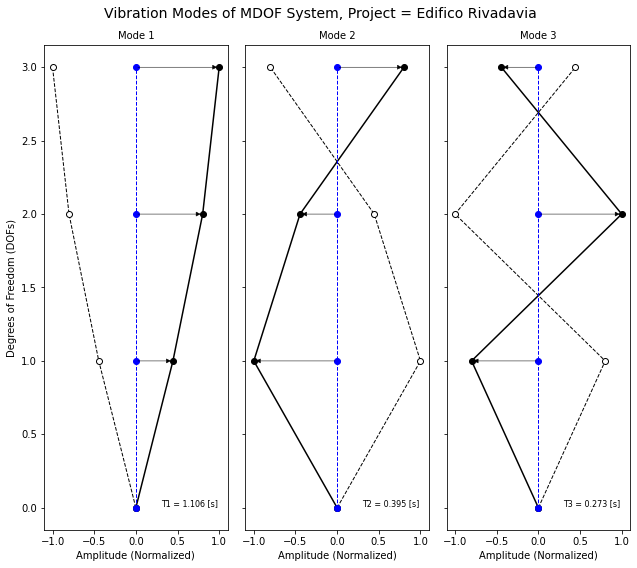

In [8]:
plotvibration = Plot_vibration(v = v_normalized,num_modes_to_plot= len(T), T = T, plotmax= 5, project= ProjecName)
plotvibration.plot_vibration_modes_subplots()

#### Calculate the modal excitation factor for each structural period (**$\{L\}$**).

$$ \{L\} = [\mathbf{\Phi}_n]^\mathrm{T} [M] \{r\} $$


In [9]:
L = np.dot(np.dot(v_normalized.T, M), r)                                                                                          # Calculation of the modal excitation factor vector {L} using the formula {L} = [Φ_n]^T [M] {r}.
L_frame = pd.DataFrame(L, columns= ['Modal excitation factor'])                                                                   # Convert the modal excitation factor vector {L} into a DataFrame for better visualization.
L_frame.head(len(L)) 

,Modal excitation factor
0,4.827942
1,-1.381797
2,-0.530669


#### Effective Modal Mass.

$$ 
   \{M_{e,i}\} = \frac{\{L_i\}^2}{\sum M_{\text{total}}} 
   $$

In [10]:
Mtotal = np.sum(np.diag(M))                                                                                                       # Calculate the total mass by summing the diagonal elements of the mass matrix M
M_e = []                                                                                                                          # Initialize a list to store the effective modal masses

for i in np.arange(0, len(T), 1):                                                                                                 # Iterate through each mode
    M_e.append(L[i]**2 / Mtotal * 100)                                                                                            # Calculate the effective modal mass for each mode and append to the list in "%"

M_e_frame = pd.DataFrame(M_e, columns= ['Effective Modal Mass [%]'])                                                              # Create a DataFrame from the effective modal mass array
M_e_frame.head(len(M_e))                                                                                                          # Display the DataFrame with effective modal masses

,Effective Modal Mass [%]
0,91.407949
1,7.487698
2,1.104353


#### Cumulative Effective Mass.

$$ 
   \{M_{e,\text{cumulative}}\} = \sum_{i=1}^{N} \{M_{e,i}\} 
   $$

In [11]:
M_e_acum = np.zeros(len(M_e))                                                                                                     # Initialize an array of zeros to store the cumulative effective modal masses
M_e_acum[0] = M_e[0]                                                                                                              # Set the first element of the cumulative array to the first effective modal mass

for i in np.arange(1, len(M_e), 1):                                                                                               # Loop through the remaining effective modal masses
    M_e_acum[i] = M_e_acum[i - 1] + M_e[i]                                                                                        # Add the current effective modal mass to the cumulative total

M_e_acum_frame = pd.DataFrame(M_e_acum, columns= ['Cumulative Effective Mass [%]'])                                               # Create a DataFrame from the cumulative effective modal mass array
M_e_acum_frame.head(len(M_e_acum))                                                                                                # Display the DataFrame with cumulative effective modal masses

,Cumulative Effective Mass [%]
0,91.407949
1,98.895647
2,100.000000


#### Spectral Analisys

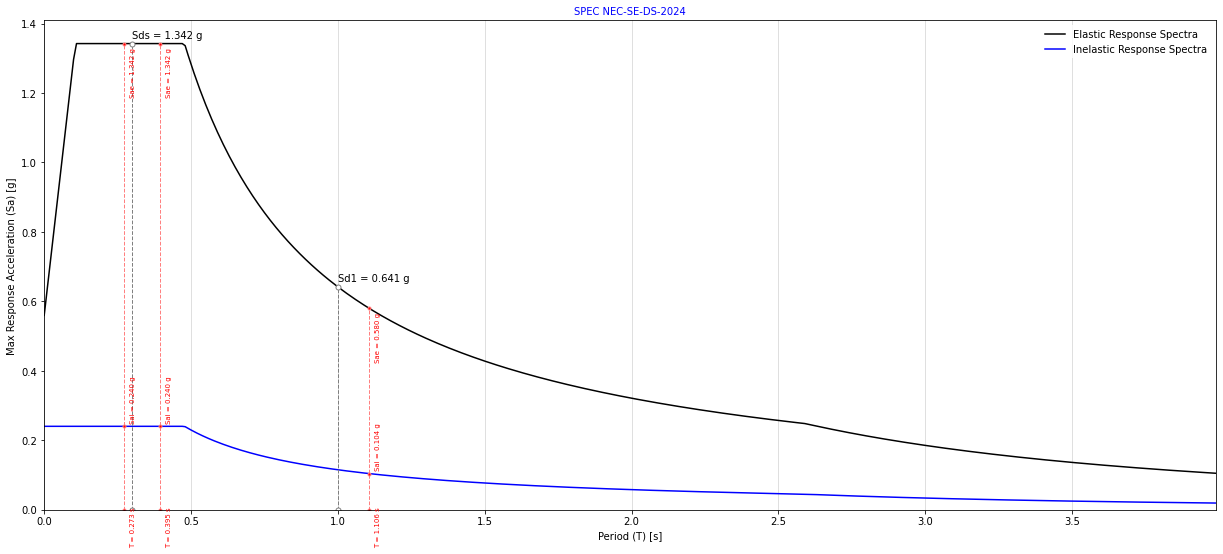

,Period [s],Sae [g],Sai [g]
0,1.106311,0.579768,0.10353
1,0.394838,1.342320,0.23970
2,0.273236,1.342320,0.23970


In [14]:
Spec = SpecNec2024_Sae_Sai_modal(Tfind = T, fads = fads, I = I, z = z, n = 2.4, R = R, r = rr, Tf = 4, dT = 0.01)
Resul = Spec.plot_SpecNEC_modal()
Resul